# Task 1: Graph Cut Segmentation

**Instructions:**

- Given 2 images (asm-1, asm-2), generate a bounding box for a person in each images by utilizing any deep learning-based object detectors (pretrain model).
- Leveraging the generated bounding boxes, implement graph-based image segmentation using OpenCV function, `cv2.grabCut`.
- Run GrabCut for 1, 3, and 5 iterations — report qualitative and quantitative differences.
- Visualize Results: Display original images, user masks, and final segmentation results (foreground only, and overlay).

**Deliverable:**

- Jupyter notebook with clear code and comments.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import torch
import torchvision
import torchvision.transforms as T
from PIL import Image

plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["axes.grid"] = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [2]:
# Show image (RGB)
def show_image(img, title=None):
    plt.figure()
    plt.imshow(img)
    plt.axis("off")
    if title:
        plt.title(title)
    plt.show()

# Show gray image
def show_gray(img, title=None):
    plt.figure()
    plt.imshow(img, cmap="gray")
    plt.axis("off")
    if title:
        plt.title(title)
    plt.show()

def show_grid(images, titles, ncols=3, cmap=None):
    n = len(images)
    nrows = int(np.ceil(n / ncols))
    plt.figure(figsize=(4*ncols, 3*nrows))
    for i, (img, t) in enumerate(zip(images, titles)):
        plt.subplot(nrows, ncols, i+1)
        if cmap is None:
            plt.imshow(img)
        else:
            plt.imshow(img, cmap=cmap)
        plt.axis("off")
        plt.title(t)
    plt.tight_layout()
    plt.show()

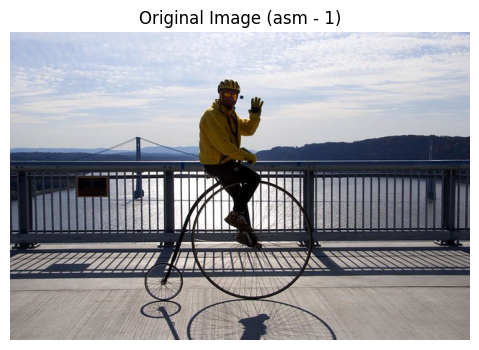

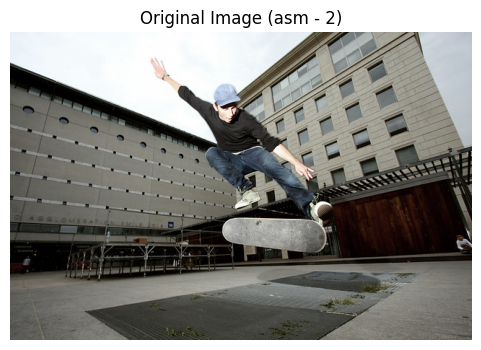

In [3]:
IMG_DIR = Path("data")
img_paths = [IMG_DIR / "asm-1.jpg",IMG_DIR / "asm-2.jpg"]

images_bgr = []
images_rgb = []

for p in img_paths:
    img_bgr = cv2.imread(str(p))
    assert img_bgr is not None, f"Cannot read image: {p}"
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    images_bgr.append(img_bgr)
    images_rgb.append(img_rgb)

for i, img in enumerate(images_rgb):
    show_image(img, f"Original Image (asm - {i+1})")

### Load Pretrained Object Detector (Faster R-CNN)

In [4]:
from torchvision.models.detection import fasterrcnn_resnet50_fpn

det_model = fasterrcnn_resnet50_fpn(weights="DEFAULT").to(device)
det_model.eval()
det_transform = T.Compose([T.ToTensor()])

### Generated bounding boxes

In [5]:
def bounding_box(pil_img, score_thresh=0.7):
    
    x = det_transform(pil_img).to(device)
    
    with torch.no_grad():
        output = det_model([x])[0]
    
    boxes = output["boxes"].cpu().numpy()
    labels = output["labels"].cpu().numpy() 
    scores = output["scores"].cpu().numpy()
    
    idxs = np.where((labels == 1) & (scores >= score_thresh))[0]
    if len(idxs) == 0:
        return None
    
    # pick the highest-score
    best = idxs[np.argmax(scores[idxs])]
    box = boxes[best].astype(int)
    return box

### Run Detection

Image (asm-1) person box: [263  63 352 298]


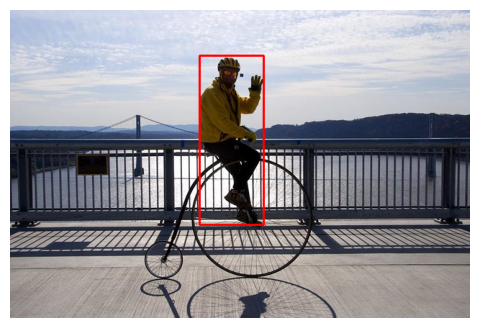

Image (asm-2) person box: [190  46 449 251]


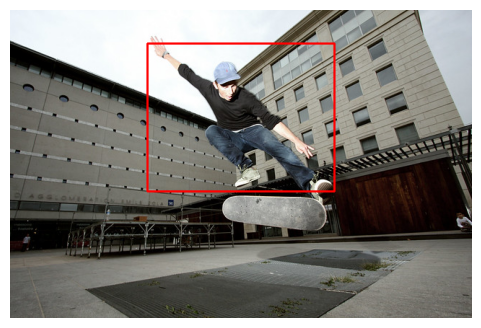

In [6]:
bounding_box_list = []
for i, img_rgb in enumerate(images_rgb):
    pil_img = Image.fromarray(img_rgb)
    box = bounding_box(pil_img, score_thresh=0.7)
    bounding_box_list.append(box)
    print(f"Image (asm-{i+1}) person box:", box)

    img_with_box = img_rgb.copy()
    if box is not None:
        x1, y1, x2, y2 = box
        cv2.rectangle(img_with_box, (x1, y1), (x2, y2), (255, 0, 0), 2)
        show_image(img_with_box)
    else:
        show_image(img_rgb)

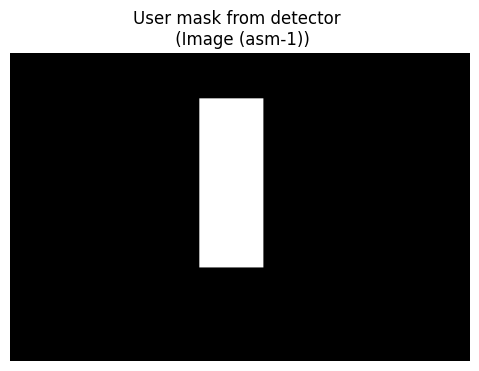

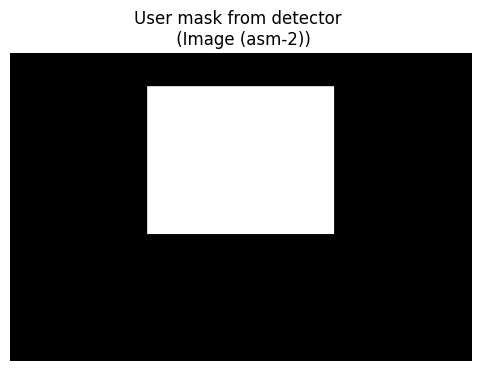

In [7]:
user_masks = []
for i, (img_rgb, box) in enumerate(zip(images_rgb,bounding_box_list)):
    h, w = img_rgb.shape[:2]
    mask = np.zeros((h, w), dtype=np.uint8)
    
    if box is not None:
        x1, y1, x2, y2 = box
        mask[y1:y2, x1:x2] = 1 
    
    user_masks.append(mask)
    show_gray(mask * 255, f"User mask from detector \n (Image (asm-{i+1}))")

### GrabCut Function

In [8]:
def grabcut_function(img_bgr, rect, iters=5):
    
    img = img_bgr.copy()
    h, w = img.shape[:2]

    mask = np.zeros((h, w), np.uint8)
    bgdModel = np.zeros((1, 65), np.float64)
    fgdModel = np.zeros((1, 65), np.float64)

    cv2.grabCut(img, mask, rect, bgdModel, fgdModel,iters, cv2.GC_INIT_WITH_RECT)
    
    mask_bin = np.where((mask == cv2.GC_FGD) | (mask == cv2.GC_PR_FGD),1, 0).astype("uint8")
    fg = img * mask_bin[:, :, np.newaxis]
    fg_rgb = cv2.cvtColor(fg, cv2.COLOR_BGR2RGB)

    return mask_bin, fg_rgb

### Run GrabCut for 1, 3, and 5 iterations

In [9]:
grabcut_results = [] 
for idx, (img_bgr, box) in enumerate(zip(images_bgr,bounding_box_list)):
    if box is None:
        print(f"Image {idx+1}: No box, skip GrabCut.")
        grabcut_results.append((None, None))
        continue
    
    x1, y1, x2, y2 = box
    rect = (x1, y1, x2 - x1, y2 - y1)

    masks = {}
    fgs = {}

    for iters in [1, 3, 5]:
        mask_bin, fg_rgb = grabcut_function(img_bgr, rect, iters=iters)
        masks[iters] = mask_bin
        fgs[iters] = fg_rgb
    
    grabcut_results.append((masks, fgs))
    print(f"Image (asm-{idx+1}): Done!!!")

Image (asm-1): Done!!!
Image (asm-2): Done!!!


### Report qualitative

In [10]:
def compute_iou(m1, m2):
    inter = np.logical_and(m1 == 1, m2 == 1).sum()
    union = np.logical_or(m1 == 1, m2 == 1).sum()
    if union == 0:
        return 0.0
    return inter / union

print(f"---------- Report qualitative and quantitative differences ----------")
for idx, (masks, fgs) in enumerate(grabcut_results):
    if masks is None:
        continue
    print(f"\n >> Quantitative comparison for Image (asm-{idx+1})")
    ref = masks[5]  
    for iters in [1, 3]:
        iou_val = compute_iou(masks[iters], ref)
        print(f"IoU(mask iters={iters} vs iters=5): {iou_val:.4f}")

    print("Foreground pixel counts:")
    for iters in [1, 3, 5]:
        fg_pixels = masks[iters].sum()
        print(f"  iters={iters}: foreground pixels = {fg_pixels}")

---------- Report qualitative and quantitative differences ----------

 >> Quantitative comparison for Image (asm-1)
IoU(mask iters=1 vs iters=5): 0.9774
IoU(mask iters=3 vs iters=5): 0.9946
Foreground pixel counts:
  iters=1: foreground pixels = 13260
  iters=3: foreground pixels = 13158
  iters=5: foreground pixels = 13111

 >> Quantitative comparison for Image (asm-2)
IoU(mask iters=1 vs iters=5): 0.6591
IoU(mask iters=3 vs iters=5): 0.5519
Foreground pixel counts:
  iters=1: foreground pixels = 21324
  iters=3: foreground pixels = 25478
  iters=5: foreground pixels = 14097


### Visualize Results: Display original images, user masks, and final segmentation results.

******* Image (asm-1) *******


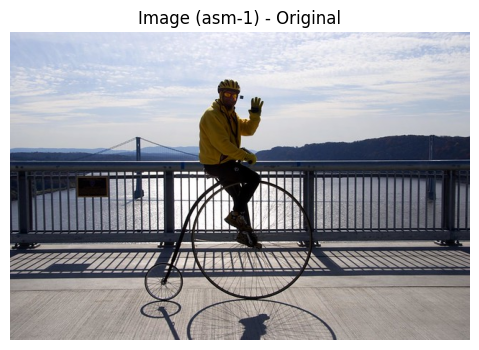

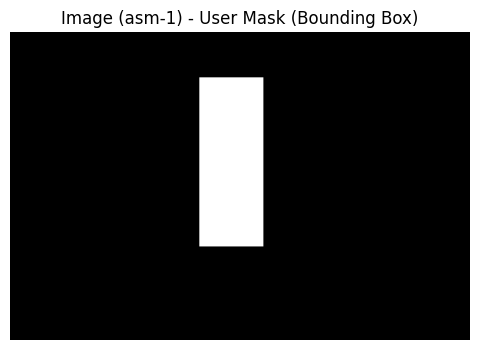

>> final segmentation results


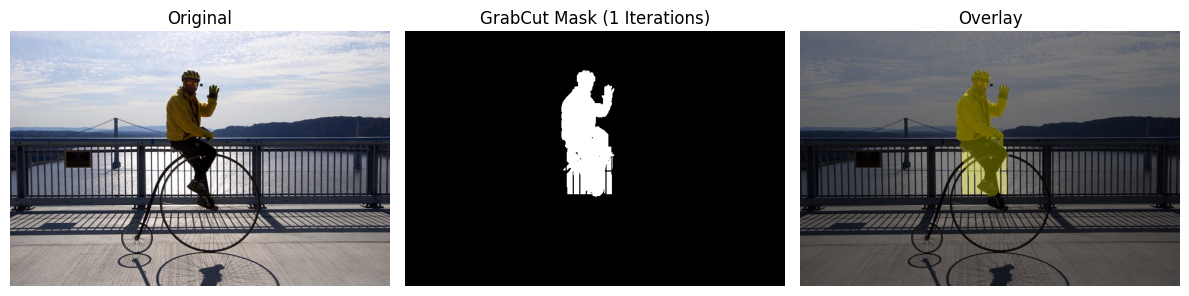

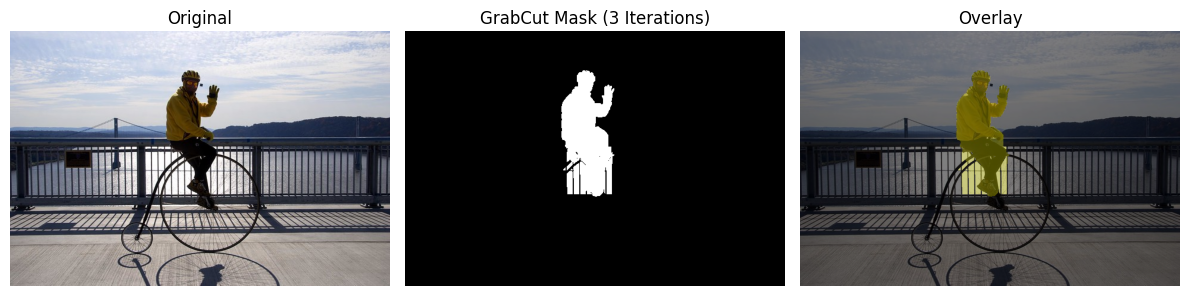

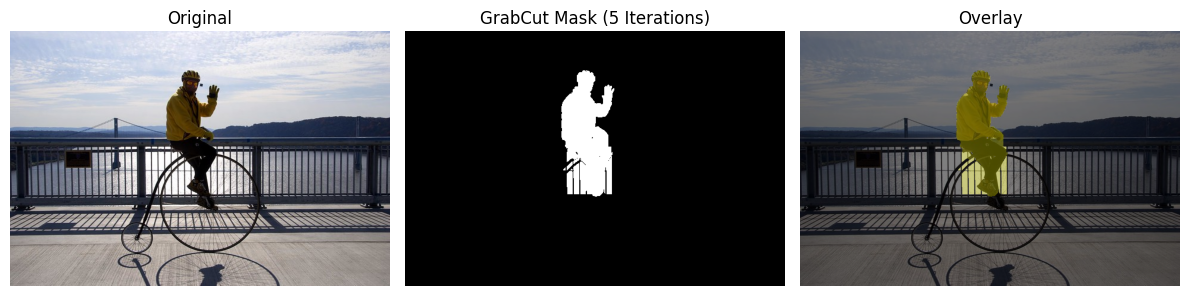

******* Image (asm-2) *******


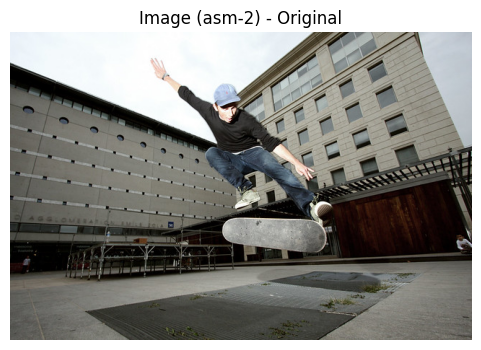

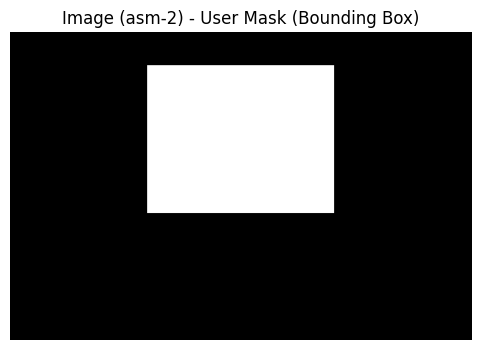

>> final segmentation results


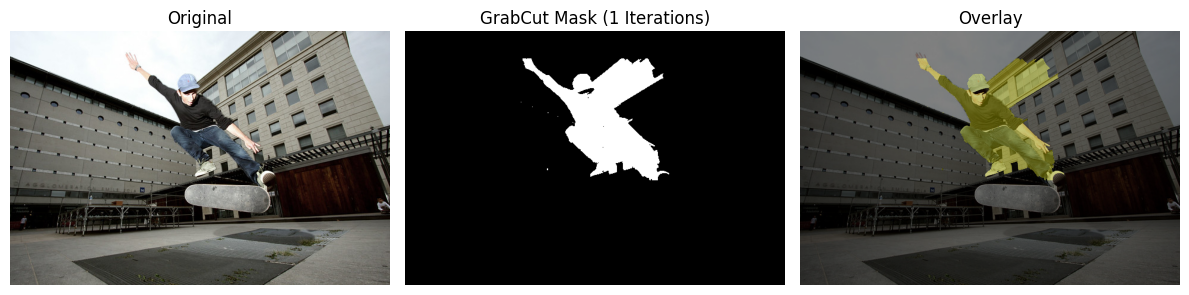

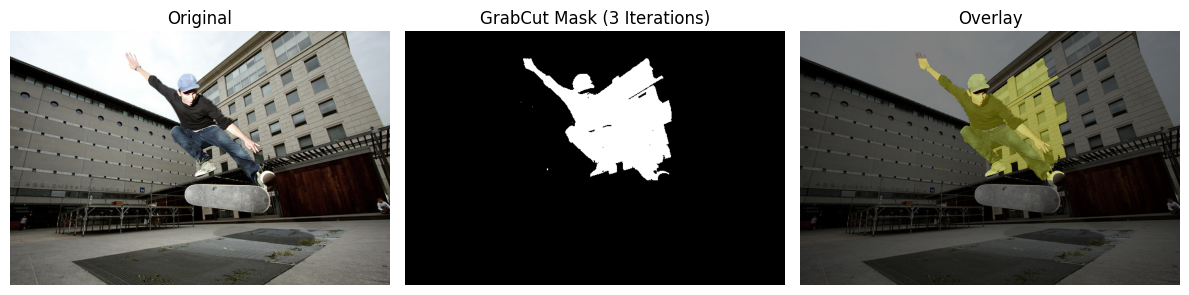

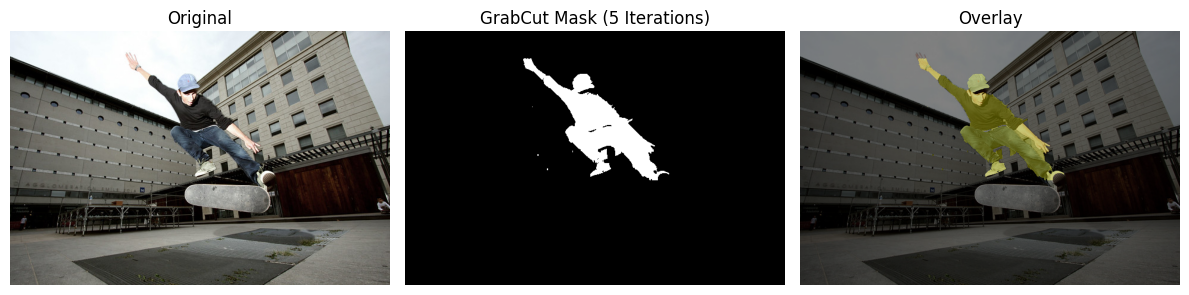

In [17]:
for idx, (img_rgb, user_mask, (masks, fgs)) in enumerate(zip(images_rgb, user_masks, grabcut_results)):
    if masks is None:
        continue

    print(f"******* Image (asm-{idx+1}) *******")
    show_image(img_rgb, f"Image (asm-{idx+1}) - Original")
    show_gray(user_mask * 255, f"Image (asm-{idx+1}) - User Mask (Bounding Box)")

    print(">> final segmentation results")
    for iters in [1, 3, 5]:
        mask_bin = masks[iters]
        fg_rgb = fgs[iters]

        overlay = img_rgb.copy()
        color_mask = np.zeros_like(img_rgb)
        color_mask[mask_bin == 1] = (150, 150, 0)  
        alpha = 0.5  # transparency
        overlay = cv2.addWeighted(img_rgb, 1 - alpha, color_mask, alpha, 0)

        # Show results
        images = [img_rgb, mask_bin * 255, overlay]
        titles = ['Original',f'GrabCut Mask ({iters} Iterations)','Overlay']
        show_grid(images, titles, ncols=3, cmap='gray')

With more iterations, GrabCut gives smoother and more accurate foreground masks.
After 3–5 iterations, the change becomes small (converged result).